<a href="https://colab.research.google.com/github/luisoleaa/Car-Price-Depreciation-Predictor/blob/main/MLSN_Team_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# we are trying to predict car depreciation (price in future)

In [ ]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
cars = pd.read_csv('/content/drive/Shareddrives/MLSN Team 8/car_prices.csv')

Mounted at /content/drive


/tmp/ipython-input-1714195463.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["odometer_bin"] = (sub["odometer"] // bin_size) * bin_size


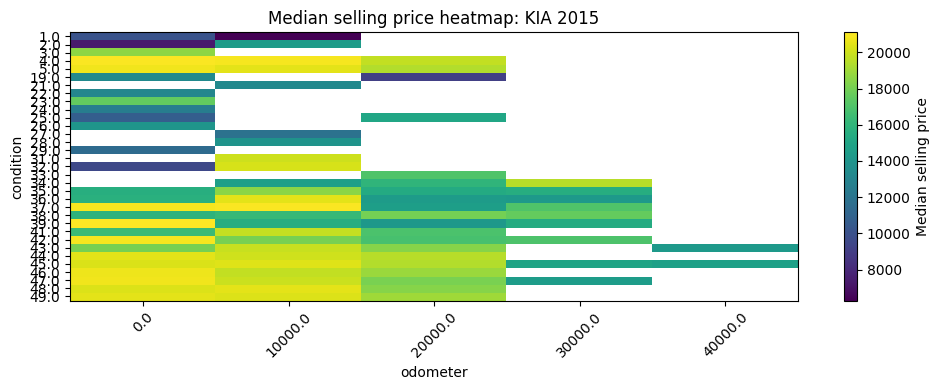

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Relates the mileage (odometer) with the condition to get the average price using a heapmap
# shows the median selling price of a specific car make in a specific year
cars = pd.read_csv('/content/drive/Shareddrives/MLSN Team 8/cars_cleaned.csv')

year_pick = 2015
make_pick = "kia"

# helps reduce the odometer's rates
bin_size = 10_000


sub = cars[(cars["year"] == year_pick) & (cars["make"] == make_pick)]
sub["odometer_bin"] = (sub["odometer"] // bin_size) * bin_size

heat = sub.pivot_table(
    index="condition",
    columns="odometer_bin",
    values="sellingprice",
    aggfunc="median"
)
# The "colder" the color, the less cars fall into that category

plt.figure(figsize=(10, 4))
plt.imshow(heat.values, aspect="auto")
plt.xticks(range(len(heat.columns)), heat.columns, rotation=45)
plt.yticks(range(len(heat.index)), heat.index)
plt.colorbar(label="Median selling price")
plt.title(f"Median selling price heatmap: {make_pick.upper()} {year_pick}")
plt.xlabel("odometer")
plt.ylabel("condition")
plt.tight_layout()
plt.show()

In [ ]:
# convert to string and lowercase
cars['make'] = cars['make'].astype('string')
cars['model'] = cars['model'].astype('string')
cars['trim'] = cars['trim'].astype('string')
cars['body'] = cars['body'].astype('string')
cars['color'] = cars['color'].astype('string')
cars['vin'] = cars['vin'].astype('string')
cars['transmission'] = cars['transmission'].astype('string')
cars['seller'] = cars['seller'].astype('string')
cars['state'] = cars['state'].astype('string')
cars['interior'] = cars['interior'].astype('string')
cars['make'] = cars['make'].str.lower()
cars['model'] = cars['model'].str.lower()
cars['trim'] = cars['trim'].str.lower()
cars['body'] = cars['body'].str.lower()
cars['color'] = cars['color'].str.lower()
cars['vin'] = cars['vin'].str.lower()
cars['transmission'] = cars['transmission'].str.lower()
cars['seller'] = cars['seller'].str.lower()
cars['state'] = cars['state'].str.lower()
cars['interior'] = cars['interior'].str.lower()

In [ ]:
# interior has some strange values, replace with empty strings first
cars.loc[cars['interior'] == '—', 'interior'] = ''
cars['interior'] = cars['interior'].replace('', pd.NA) # then turn them into missing
# same with color
cars.loc[cars['color'] == '—', 'color'] = '' # then turn them into missing
cars['color'] = cars['color'].replace('', pd.NA)
cars.iloc[16] # example row where this is a problem
cars.iloc[134]

,134
year,2013
make,infiniti
model,g sedan
trim,g37 journey
body,g sedan
transmission,automatic
vin,jn1cv6ap1dm302069
state,ca
condition,37.0
odometer,21144.0


In [ ]:
# using Diego's research
# make a function that will do this missing replacement
def fill_transmission(row):
    # only try to fill if value is missing
    if pd.isna(row['transmission']):
        model = row['model']
        year = row['year']

        # Check if model not na before comparing
        if pd.isna(model):
            return row['transmission'] # return original value if model is na

        # if 100% certain change into automatic
        if model == 'escape' and year >= 2013:
            return 'automatic'
        if model == 'explorer' and year >= 2011:
            return 'automatic'
        if model == 'maxima' and year >= 2000:
            return 'automatic'
        if model == 'rogue' and year >= 2014:
            return 'automatic'
        # Altimas, Camrys, and 3 Series skipped because of uncertainty

    return row['transmission']

# apply function
cars['transmission'] = cars.apply(fill_transmission, axis=1)

cars.info() #verify change, can see more non-null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  string 
 2   model         548438 non-null  string 
 3   trim          548186 non-null  string 
 4   body          545642 non-null  string 
 5   transmission  495523 non-null  object 
 6   vin           558833 non-null  string 
 7   state         558837 non-null  string 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         533403 non-null  string 
 11  interior      541011 non-null  string 
 12  seller        558837 non-null  string 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
 16  odometer_bin  558743 non-null  float64
dtypes: float64(5), int64(1), object(2), string(9)
me

In [ ]:
# turns all transmissions into 0 (automatic) and 1 (manual), overriding original transmission column
cars['transmission'] = cars['transmission'].map({'automatic': 0, 'manual': 1})

In [ ]:
# convert to datetime
# specifying utc=True to help parse and create a consistent datetime column by normalizing to UTC (for simplicity since only want mdy)
cars['clean_date'] = pd.to_datetime(cars['saledate'], errors='coerce', utc=True)

# format to mdy for simplicity/represent original but can rearrange if needed
cars['formatted_date'] = cars['clean_date'].dt.strftime('%b %d %Y')
# drop old date columns and keep the cleaned/properly formatted one only
cars = cars.drop(columns=['saledate', 'clean_date'])
cars['formatted_date'] = pd.to_datetime(cars['formatted_date'])
cars.info()

/tmp/ipython-input-64477398.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cars['clean_date'] = pd.to_datetime(cars['saledate'], errors='coerce', utc=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   year            558837 non-null  int64         
 1   make            548536 non-null  string        
 2   model           548438 non-null  string        
 3   trim            548186 non-null  string        
 4   body            545642 non-null  string        
 5   transmission    493459 non-null  float64       
 6   vin             558833 non-null  string        
 7   state           558837 non-null  string        
 8   condition       547017 non-null  float64       
 9   odometer        558743 non-null  float64       
 10  color           533403 non-null  string        
 11  interior        541011 non-null  string        
 12  seller          558837 non-null  string        
 13  mmr             558799 non-null  float64       
 14  sellingprice    558825 non-null  flo

#CatBoost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.2 MB/s eta 0:00:00


In [ ]:
import catboost as cb
from catboost import CatBoostClassifier
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
cat_cars = cars
cat_cars['formatted_date'] = pd.to_datetime(cat_cars['formatted_date'])
cat_cars['sale_year'] = cat_cars['formatted_date'].dt.year
cat_cars['sale_month'] = cat_cars['formatted_date'].dt.month
cat_cars['car_age'] = cat_cars['sale_year'] - cat_cars['year']  # How old the car is when sold


# Drop columns we don't need
# VIN is unique to each car - won't help predict price
cars_clean = cat_cars.drop(['formatted_date', 'vin', 'mmr'], axis=1).copy()

# Handle missing values in numerical columns
cars_clean['condition'] = cars_clean['condition'].fillna(cars_clean['condition'].median())
cars_clean['odometer'] = cars_clean['odometer'].fillna(cars_clean['odometer'].median())

cars_clean = cars_clean.dropna(subset=['sellingprice'])

In [ ]:
cat_cols = ['make', 'model', 'trim', 'body', 'state', 'color', 'interior', 'seller']
for col in cat_cols:
  cars_clean[col] = cars_clean[col].fillna('unknown').astype(str)

#drop target
X = cars_clean.drop('sellingprice', axis=1)
y = cars_clean['sellingprice']

categorical_features_indices = [X.columns.get_loc(col) for col in cat_cols]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=50)
model.fit(X_train, y_train, cat_features=categorical_features_indices, eval_set=(X_test, y_test))

predictions = model.predict(X_test)


0:	learn: 9161.5172569	test: 9183.7924295	best: 9183.7924295 (0)	total: 347ms	remaining: 34.4s
50:	learn: 4435.7658300	test: 4425.3680394	best: 4425.3680394 (50)	total: 12.5s	remaining: 12s
99:	learn: 3995.5503975	test: 3975.8976282	best: 3975.8976282 (99)	total: 23.3s	remaining: 0us

bestTest = 3975.897628
bestIteration = 99



#Grid Search


In [ ]:
#GRID SEARCH

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=categorical_features_indices
)


param_grid = {
    'iterations':   [100, 200, 300],
    'learning_rate':  [0.01, 0.05, 0.1],
    'depth':  [4, 6, 8]
}

#create a new model
gs_model = CatBoostRegressor(loss_function = 'RMSE', task_type='GPU', random_seed = 42, verbose = False)

#run grid search
#x_train and y_train are from same train_test_split

grid_search_result = gs_model.grid_search(
    param_grid,
    X = train_pool,
    cv =3,
    verbose = True #only print summary
)

#Best parameter combination:
best_params = grid_search_result['params']
print("Best parameters found using grid search:")
print(best_params)



bestTest = 8386.434668
bestIteration = 99
0:	loss: 8386.4346684	best: 8386.4346684 (0)	total: 3.11s	remaining: 1m 20s
bestTest = 4763.575509
bestIteration = 99
1:	loss: 4763.5755088	best: 4763.5755088 (1)	total: 5.75s	remaining: 1m 11s
bestTest = 4349.633552
bestIteration = 99
2:	loss: 4349.6335523	best: 4349.6335523 (2)	total: 8.42s	remaining: 1m 7s
bestTest = 5539.269079
bestIteration = 199
3:	loss: 5539.2690794	best: 4349.6335523 (2)	total: 18.3s	remaining: 1m 45s
bestTest = 3876.813909
bestIteration = 199
4:	loss: 3876.8139090	best: 3876.8139090 (4)	total: 28.1s	remaining: 2m 3s
bestTest = 3507.788017
bestIteration = 199
5:	loss: 3507.7880167	best: 3507.7880167 (5)	total: 35.4s	remaining: 2m 4s
bestTest = 4781.17929
bestIteration = 299
6:	loss: 4781.1792897	best: 3507.7880167 (5)	total: 48.8s	remaining: 2m 19s
bestTest = 3671.573231
bestIteration = 299
7:	loss: 3671.5732313	best: 3507.7880167 (5)	total: 1m 1s	remaining: 2m 25s
bestTest = 3303.845805
bestIteration = 299
8:	loss: 330

In [ ]:
#model using the best parameters
tuned_model = CatBoostRegressor(
    **best_params,
    loss_function = 'RMSE',
    task_type='GPU',
    random_seed = 42,
    verbose = 50
)

tuned_model.fit(
    X_train, y_train,
    cat_features = categorical_features_indices,
    eval_set = (X_test, y_test)
)

#predict
tuned_predictions = tuned_model.predict(X_test)

mae = mean_absolute_error(y_test, tuned_predictions)
rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))
mape = np.mean(np.abs((y_test - tuned_predictions) / y_test)) * 100
mean_price = np.mean(y_test)
rmse_pct = (rmse / mean_price) * 100

print(f'\n Tuned model performance on test set:')
print(f'   MAE  (Mean Absolute Error):       ${mae:,.2f}')
print(f'   RMSE (Root Mean Squared Error):   ${rmse:,.2f}')
print(f'   rmse_pct:   %{rmse_pct:,.2f}')

In [ ]:
# Catboost Random Search
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor

# find indices of categorical features, 'cat_cols' and 'X' are available in kernel state
cat_features_indices = [X.columns.get_loc(c) for c in cat_cols]

# define parameter grid
param_grid = {
    'iterations': [500], # keep it low for search to save time
    'learning_rate': [0.03, 0.1, 0.15],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 9],
    'border_count': [32, 50, 100]
}

# initialize model, use GPU for efficiency
model = CatBoostRegressor(
    task_type="GPU",
    random_seed=42,
    cat_features=cat_features_indices,
    verbose=False
)

# Random Search
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=5, # 5 different combinations
    cv=3,     # 3-fold Cross-Validation
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1 # Use all available processors
)

# search: used a sample of 50k rows instead of all 550k to find parameters fast
random_search.fit(X_train.sample(50000, random_state=42), y_train.sample(50000, random_state=42))

print(f"Best Parameters: {random_search.best_params_}")

In [ ]:
# Use parameters for CatBoost Random Search model
from catboost import CatBoostRegressor, Pool

# define dictionary with best parameters
best_params = {
    'learning_rate': 0.15,
    'l2_leaf_reg': 1,
    'iterations': 500,
    'depth': 8,
    'border_count': 50
}

# initialize CatBoostRegressor model with best_params
final_model = CatBoostRegressor(
    **best_params,
    task_type="GPU",
    random_seed=42,
    cat_features=cat_features_indices,
    verbose=True  # to see progress
)

# create Pool object for the full training dataset using features defined in kernel state
train_pool_full = Pool(X_train, y_train, cat_features=cat_features_indices)

# train model on full training Pool
final_model.fit(train_pool_full)

from sklearn.metrics import mean_squared_error # for accuracy testing

# predict on test set
y_pred = final_model.predict(X_test)

# calculate RMSE, which is sqrt of mse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE on X_test for CatBoost random search: {rmse:.2f}")


In [ ]:
# Luis's Random Forest model with Grid Search Hyperparameter tuning
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



df = pd.read_csv('cars_cleaned.csv')
df_clean = df.dropna().copy()

# categorical columns used in frequency encoded
cat_features = ["make", "model", "trim", "body", "transmission", "state", "color", "interior", "seller"]


# frequency encoding thingy
# for each categorical column, replace the category name with its count in the dataset
for col in cat_features:
    freq = df_clean[col].value_counts()
    df_clean[f'{col}_freq'] = df_clean[col].map(freq)

# numrtic columns ones
num_features = ['year', 'condition', 'odometer', 'mmr']

# numeric features +  frequency encoded stuff

feature_cols = num_features + [f'{col}_freq' for col in cat_features]

X = df_clean[feature_cols]
y = df_clean['sellingprice']

# #split Data (80% train, 20% test)
# rf_model = RandomForestRegressor(random_state=42)
# # parameter grid for GRID SEARCH
# param_grid = {
#     'n_estimators': [100, 300],
#     'max_depth': [None, 20, 50],
#     #'min_samples_split': [2, 10],
#     # 'min_samples_leaf': [1, 2, 4],
#     # 'max_features': ['sqrt', 'log2']
# }
# grid_search = GridSearchCV(
#     estimator=rf_model,
#     param_grid=param_grid,
#     cv=5,                # 5-fold cross validation
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,           # Use all cores
#     verbose=2
# )

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Grid search
# grid_search.fit(X_train, y_train)
# print("GRID SEARCH BEST PARAMETERS:\n")
# print(grid_search.best_params_)
# best_rf = grid_search.best_estimator_

# Test removing MMR
print("\n" + "=" * 50)
print("### Testing Without MMR Feature")
print("=" * 50)

feature_cols_no_mmr = [f for f in feature_cols if f != 'mmr']
X_no_mmr = df_clean[feature_cols_no_mmr]

X_train_no_mmr, X_test_no_mmr, y_train_no_mmr, y_test_no_mmr = train_test_split(
    X_no_mmr, y, test_size=0.2, random_state=42
)

rf_model_no_mmr = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20)
rf_model_no_mmr.fit(X_train_no_mmr, y_train_no_mmr)

y_pred_no_mmr = rf_model_no_mmr.predict(X_test_no_mmr)

mae_no_mmr = mean_absolute_error(y_test_no_mmr, y_pred_no_mmr)
rmse_no_mmr = np.sqrt(mean_squared_error(y_test_no_mmr, y_pred_no_mmr))
r2_no_mmr = r2_score(y_test_no_mmr, y_pred_no_mmr)

print("\nModel WITHOUT MMR:")
print(f"R-squared Score: {r2_no_mmr:.4f}")
print(f"MAE: ${mae_no_mmr:,.2f}")
print(f"RMSE: ${rmse_no_mmr:,.2f}")

# Random Search


In [ ]:
param_distributions = {
    "n_estimators": randint(200, 500),
    #"max_depth": randint(10, 30),
    #"max_features": [None], #should be better at None which is 1.0
    #"min_samples_split": randint(2,20),
    #"min_samples_leaf": randint(1,10),
    #"random_state": [42],
    #"oob_score": [False],
    #"n_jobs": [-1]
}

# randomized search finds the best hyperparameters
random_search = RandomizedSearchCV(rf_model, param_distributions, n_iter=20, cv=2, n_jobs=1, verbose=2) #unsure with number of iterations
random_search.fit(X, y)

# Parameter which gives the best results
print(f"Best Hyperparameters: {random_search.best_params_}")

# Accuracy of the model after using best parameters
print(f"Best Score: {random_search.best_score_}")
'''
'''
#Random Search CV - i just copy pasted what as earlier but changed w new parameters
rf_model = RandomForestRegressor(n_estimators=48, max_depth=23, max_features= None,
                                  min_samples_split=4, min_samples_leaf=1, n_jobs=-1, random_state=42, oob_score=True)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("### Model Performance w/ RS")
print(f"R-squared Score: {r2:.6f}") # closer to 1.0 is better
print(f"MAE: ${mae:,.2f}") # average error in dollars
print(f"RMSE: ${rmse:,.2f}") # idrk
oob_error = 1 - rf_model.oob_score_

# Print the OOB error
print(f'OOB error: {oob_error:.3f}')

# k-fold: https://www.geeksforgeeks.org/machine-learning/k-fold-cross-validation-in-machine-learning/
# has one specifically for regression: https://www.geeksforgeeks.org/machine-learning/cross-validation-using-k-fold-with-scikit-learn/

#the 5 is the number of splits so test: 1/5 train 4/5
k = 5  # use 10 to n for lower variance but result in longer comp time, 2 for test
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Perform Cross Validation
scores = cross_val_score(rf_model, X, y, cv=kf, scoring="r2")

print(f"Accuracy for each fold: {scores}")

average_accuracy = np.mean(scores)
print(f"Average Accuracy: {average_accuracy:.5f}")

 '''


#Bayesian Opt
search_space = {
    "n_estimators": Integer(330,440) # ->420
    #"max_depth": Integer(30,40)
    #"max_features": Categorical([None]),
    #"min_samples_split": Integer(2,6), ->3
    #"min_samples_leaf": Integer(1,3) -> 1
    #"random_state": Categorical([42]),
    #"oob_score": Categorical([False]),
    #"n_jobs": Categorical([-1])
}
'''
#ran into a problem where it can crash? tried removing the single value parameters and just default it inside rf_model
rf_model = RandomForestRegressor(max_features= 1.0, n_jobs=-1, random_state=42, oob_score=True, min_samples_split=3, min_samples_leaf=1, max_depth=33)
#also changed max_features from None to 1.0. Number = better?

#changed bayes n_jobs to 1, so it runs through trees at full, and each fold at atime
#its -1 im not waiting 6 hrs
bayes_search = BayesSearchCV(
    estimator = rf_model, search_spaces=search_space, n_iter=20, cv=5,n_jobs=-1,random_state= 42, verbose=2, optimizer_kwargs={
        "base_estimator": "GP",
          "acq_func": "EI"
    }
)

bayes_search.fit(X_train, y_train)
print(f"Best Params: {bayes_search.best_params_}")
print(f"Best Score: {bayes_search.best_score_}")
'''

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

hp_model = RandomForestRegressor(max_features= 1.0, n_jobs=-1, random_state=42, oob_score=True,
                                 min_samples_split=3, min_samples_leaf=1, max_depth=33, n_estimators=420)

hp_model.fit(X_train, y_train)
